In [1]:
import pandas as pd

# load dataset
df = pd.read_csv('paysim.csv')  # ganti sesuai nama file kamu

# lihat 5 data awal
print(df.head())

# cek jumlah baris & kolom
print("Shape data:", df.shape)

# info dataset
print(df.info())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
Shape data: (6362620, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619

In [2]:
# jumlah missing values per kolom
missing_values = df.isnull().sum()

print("Missing values per kolom:")
print(missing_values)

# total missing values
print("\nTotal missing values:", missing_values.sum())

Missing values per kolom:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total missing values: 0


In [3]:
# hitung jumlah fraud vs non-fraud
fraud_counts = df['isFraud'].value_counts()

print("Distribusi Fraud:")
print(fraud_counts)

# dalam persen
fraud_percentage = df['isFraud'].value_counts(normalize=True) * 100

print("\nDistribusi Fraud (%):")
print(fraud_percentage)

Distribusi Fraud:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Distribusi Fraud (%):
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


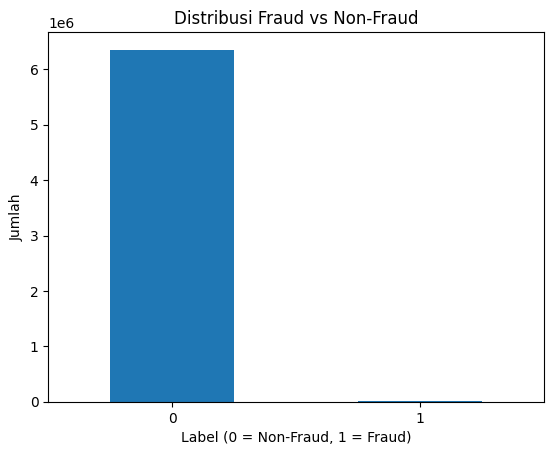

In [4]:
import matplotlib.pyplot as plt

# plot distribusi fraud
fraud_counts.plot(kind='bar')
plt.title('Distribusi Fraud vs Non-Fraud')
plt.xlabel('Label (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

In [5]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

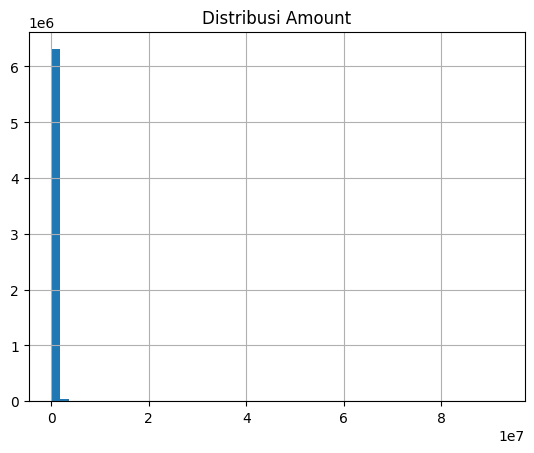

In [6]:
import matplotlib.pyplot as plt

df['amount'].hist(bins=50)
plt.title('Distribusi Amount')
plt.show()

In [7]:
df[df['isFraud'] == 1]['amount'].describe()
df[df['isFraud'] == 0]['amount'].describe()

count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

In [8]:
df[['oldbalanceOrg','newbalanceOrig']].head()

,oldbalanceOrg,newbalanceOrig
0,170136.0,160296.36
1,21249.0,19384.72
2,181.0,0.00
3,181.0,0.00
4,41554.0,29885.86
